In [9]:
%load_ext autoreload
%autoreload 2
import os
import sys
import json
import numpy as np
import pandas as pd
import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

MPL_CUSTOM = {
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 120,
    'figure.figsize': (4, 3.5),
    'figure.facecolor': 'white',
    'xtick.top': True,
    'xtick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.right': True,
    'ytick.direction': 'in',
    'ytick.minor.visible': True,
}

for k, v in MPL_CUSTOM.items():
    mpl.rcParams[k] = v

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
try:
    import ROOT
except ImportError as e:
    env_lib = Path(os.environ['CONDA_PREFIX']) / 'lib'
    sys.path.append(list(env_lib.glob('python*/site-packages'))[-1])
    import ROOT


In [11]:
def TH1D_to_df(hist,  xname='x', yname='y', keep_zeros=True):
    df = dict()
    columns = [xname, yname, f'{yname}_err']
    getters = [hist.GetXaxis().GetBinCenter, hist.GetBinContent,
                hist.GetBinError]
    for col, get in zip(columns, getters):
        df[col] = [get(b) for b in range(1, hist.GetNbinsX() + 1)]

    df = pd.DataFrame(df)
    condition = (df[yname] != 0.0)
    df[f'{yname}_ferr'] = np.where(
        condition, np.abs(df[f'{yname}_err']/df[yname]), 0.0)

    return df if keep_zeros else df.query(f'{yname} != 0.0').reset_index(drop=True)


def TH2D_to_df(histo, xname='x', yname='y', zname='z', keep_zeros=True):
    x = np.array([histo.GetXaxis().GetBinCenter(b)
                    for b in range(1, histo.GetNbinsX() + 1)])
    y = np.array([histo.GetYaxis().GetBinCenter(b)
                    for b in range(1, histo.GetNbinsY() + 1)])

    content = np.array(histo)
    content = content.reshape(len(x) + 2, len(y) + 2, order='F')
    content = content[1:-1, 1:-1]

    error = np.array([histo.GetBinError(b)
                        for b in range((len(x) + 2) * (len(y) + 2))])
    error = error.reshape(len(x) + 2, len(y) + 2, order='F')
    error = error[1:-1, 1:-1]

    xx, yy = np.meshgrid(x, y, indexing='ij')
    df = pd.DataFrame({
        xname: xx.flatten(),
        yname: yy.flatten(),
        zname: content.flatten(),
        f'{zname}_err': error.flatten(),
    })
    mask = (df[zname] != 0.0)
    df[f'{zname}_ferr'] = np.where(
        mask,
        np.abs(df[f'{zname}_err'] / df[zname]),
        0.0
    )
    return df if keep_zeros else df.query(f'{zname} != 0.0').reset_index(drop=True)


In [12]:
current_dir = Path.cwd()
main_dir = current_dir.parent

In [13]:
shadow_bars = [2,3,4]

interested_bar = {
    'bar2' : 2,
    'bar3' : 3,
    'bar4' : 4,
}

shadow_bar_placed = {
    'bar2' : [2,3],
    'bar3' : [2,3,4],
    'bar4' : [3,4],
    'bar23_only' : [2,3],
    'bar34_only' : [3,4],
    'bar4_only' : [4],
}

In [14]:
hist_name = 'hBarHitPattern'

In [15]:
def get_histogram(pth, hist_name, clone_name):
    file = ROOT.TFile(pth, 'read')
    return TH2D_to_df(file.Get(hist_name).Clone(clone_name))

# run name (named by shadow bar used, e.g. run23.root) -> 2d histogram
histograms = {
    shadowbar : get_histogram(
        str(main_dir / 'results/shadow/all' / f'{shadowbar}.root'), hist_name, hist_name + '_' + shadowbar
    ) for shadowbar in shadow_bar_placed.keys()
}

In [16]:
shadow_bar_coordinates = {
    1 : [(280,181), (280,274), (182,274), (182,181)],
    2 : [(-184,181), (-184,274), (-278,274), (-277,181)],
    3 : [(-181,-276), (-181,-184), (-280,-184), (-280,-277)],
    4 : [(277,-279), (276,-181), (184,-181), (185,-280)],
    5 : [(80,-25), (80,-67), (-28,-67), (-28,-25)],
}

In [17]:
def projection(df, x_range, y_range, bins, axis='x'):
    cut_axis = 'x' if axis == 'y' else 'y'
    cut_range = x_range if axis == 'y' else y_range
    hist_range = x_range if axis == 'x' else y_range
    
    df = df.query(f'{cut_axis} > {cut_range[0]} and {cut_axis} < {cut_range[1]}')
    hist, edges = np.histogram(
        df[axis], bins, range=hist_range, weights=df['z'])
    hist_err, _ = np.histogram(
        df[axis], bins, range=hist_range, weights=df['z_err']**2)
    hist_err = np.sqrt(hist_err)
    x = (edges[1:] + edges[:-1]) / 2
    return pd.DataFrame({
        'x': x,
        'y': hist,
        'y_err': hist_err,
        'y_ferr': np.divide(hist_err, hist, out=np.zeros_like(hist), where=hist!=0)
    })


In [18]:
df_mod_pos = pd.read_csv(
    main_dir / 'database/module_positions.dat',
    sep=r'\s+',
    skiprows=1,
)

module_ids = df_mod_pos['id'].values
layer_ids = df_mod_pos['layer_id'].values
module_x = df_mod_pos['x'].values * 1000
bar_width = 40 # mm

covered_modules = {
    bar_id : [] for bar_id in shadow_bar_coordinates.keys()
}
for bar_id, coor in shadow_bar_coordinates.items():
    xrange = sorted([coor[0][0], coor[2][0]])
    yrange = sorted([coor[0][1], coor[1][1]])
    print(f'xrange : {xrange} yrange : {yrange}')

    for module_id, layer_id, x in zip(module_ids, layer_ids, module_x):
        if (layer_id == 0 or layer_id == 2) and x - bar_width / 2 > yrange[0] and x + bar_width / 2 < yrange[1]:
            covered_modules[bar_id].append(module_id)
        elif layer_id == 1 and x - bar_width / 2 > xrange[0] and x + bar_width / 2 < xrange[1]:
            covered_modules[bar_id].append(module_id)

covered_modules

xrange : [182, 280] yrange : [181, 274]
xrange : [-278, -184] yrange : [181, 274]
xrange : [-280, -181] yrange : [-276, -184]
xrange : [184, 277] yrange : [-279, -181]
xrange : [-28, 80] yrange : [-67, -25]


{1: [6, 30, 54], 2: [6, 41, 54], 3: [17, 41, 65], 4: [17, 30, 65], 5: [35]}

In [19]:
module_gates = itertools.chain.from_iterable([covered_modules[bar_id] for bar_id in shadow_bars])
module_gates = list(set(module_gates)) 
module_gates = sorted(module_gates)
module_gates
# [6, 17, 30, 41, 54, 65]

[6, 17, 30, 41, 54, 65]

In [20]:
# [shadowbar used][module id] -> df
hist_shadow = {}
bins = 25

for run in histograms.keys():
    df = histograms[run].copy()
    hist_shadow[run] = {
        mod : projection(df, x_range=(-1000, 1000), y_range=(mod, mod + 1), bins=bins, axis='x') for mod in module_gates
    }


In [21]:
# shadow bar id -> run name which does not have the shadow bar
shadow_ref = {
    'bar2' : 'bar4', # run with shadow bar (2,3); ref : runs with shadow bar (3,4)+(4)
    'bar3' : 'bar4_only', # run with shadow bar (2,3)+(3,4); runs with shadow bar (4)
    'bar4' : 'bar23_only', # run with shadow bar (3,4)+(4); runs with shadow bar (2,3)
}


0.27092749205250827

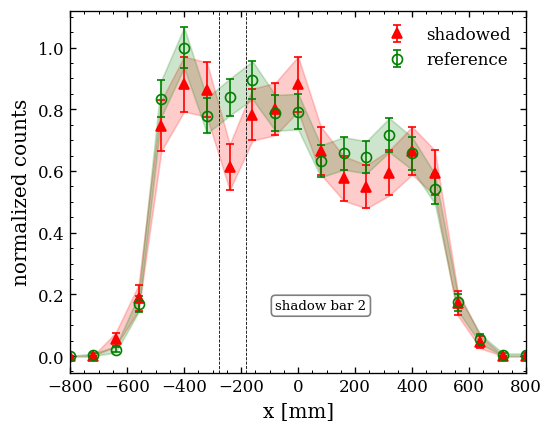

In [22]:
target_shadow = 2
target_run = 'bar2'
shadow_module = 54

fig, ax = plt.subplots(1, 1, figsize=(4.5,3.5), dpi=120, constrained_layout=True)

norm = hist_shadow[target_run][shadow_module]['y'].values.max()
norm = max(norm, hist_shadow[shadow_ref[target_run]][shadow_module]['y'].values.max())

ax.errorbar(
    hist_shadow[target_run][shadow_module]['x'],
    hist_shadow[target_run][shadow_module]['y'] / norm,
    yerr=hist_shadow[target_run][shadow_module]['y_err'] / norm,
    elinewidth=1,
    capsize=2.5,
    marker='^',
    ls='none',
    color='r',
    label='shadowed'
)

ax.errorbar(
    hist_shadow[shadow_ref[target_run]][shadow_module]['x'],
    hist_shadow[shadow_ref[target_run]][shadow_module]['y'] / norm,
    yerr=hist_shadow[shadow_ref[target_run]][shadow_module]['y_err'] / norm,
    elinewidth=1,
    capsize=2.5,
    marker='o',
    ls='none',
    color='g',
    markerfacecolor='none',
    label='reference'
)

ax.fill_between(
    hist_shadow[target_run][shadow_module]['x'],
    (hist_shadow[target_run][shadow_module]['y'] - hist_shadow[target_run][shadow_module]['y_err']) / norm, 
    (hist_shadow[target_run][shadow_module]['y'] + hist_shadow[target_run][shadow_module]['y_err']) / norm,
    color='r',
    alpha=0.2
)

ax.fill_between(
    hist_shadow[shadow_ref[target_run]][shadow_module]['x'],
    (hist_shadow[shadow_ref[target_run]][shadow_module]['y'] - hist_shadow[shadow_ref[target_run]][shadow_module]['y_err']) / norm,
    (hist_shadow[shadow_ref[target_run]][shadow_module]['y'] + hist_shadow[shadow_ref[target_run]][shadow_module]['y_err']) / norm,
    color='g',
    alpha=0.2
)

ax.axvline(shadow_bar_coordinates[target_shadow][0][0], color='k', linestyle='--', linewidth=0.5)
ax.axvline(shadow_bar_coordinates[target_shadow][2][0], color='k', linestyle='--', linewidth=0.5)

ax.legend(
    loc='upper right',
    fontsize=10,
    frameon=False
)

ax.set_xlim(-800,800)
ax.set_xlabel('x [mm]', fontsize=12)
ax.set_ylabel('normalized counts', fontsize=12)
ax.annotate(
    fr'shadow bar {target_shadow}',
    xy=(0.55, 0.175),
    xycoords='axes fraction',
    fontsize=8,
    ha='center',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

xrange = sorted([shadow_bar_coordinates[target_shadow][0][0], shadow_bar_coordinates[target_shadow][2][0]])

ref_counts = hist_shadow[shadow_ref[target_run]][shadow_module].query(f'x > {xrange[0]} and x < {xrange[1]}')

shadow_counts = hist_shadow[target_run][shadow_module].query(f'x > {xrange[0]} and x < {xrange[1]}')

ratio=(ref_counts['y'].sum() - shadow_counts['y'].sum()) / ref_counts['y'].sum()
ratio

shadowbar 2 : module 6 : 0.18216625374163942
shadowbar 2 : module 41 : 0.4134126377620605
shadowbar 2 : module 54 : 0.27092749205250827
shadowbar 3 : module 17 : 0.1427495281823576
shadowbar 3 : module 41 : 0.12106569905905974
shadowbar 3 : module 65 : 0.19343990145048615
shadowbar 4 : module 17 : 0.06629872431706392
shadowbar 4 : module 30 : 0.08031826299098163
shadowbar 4 : module 65 : 0.21490583426059418


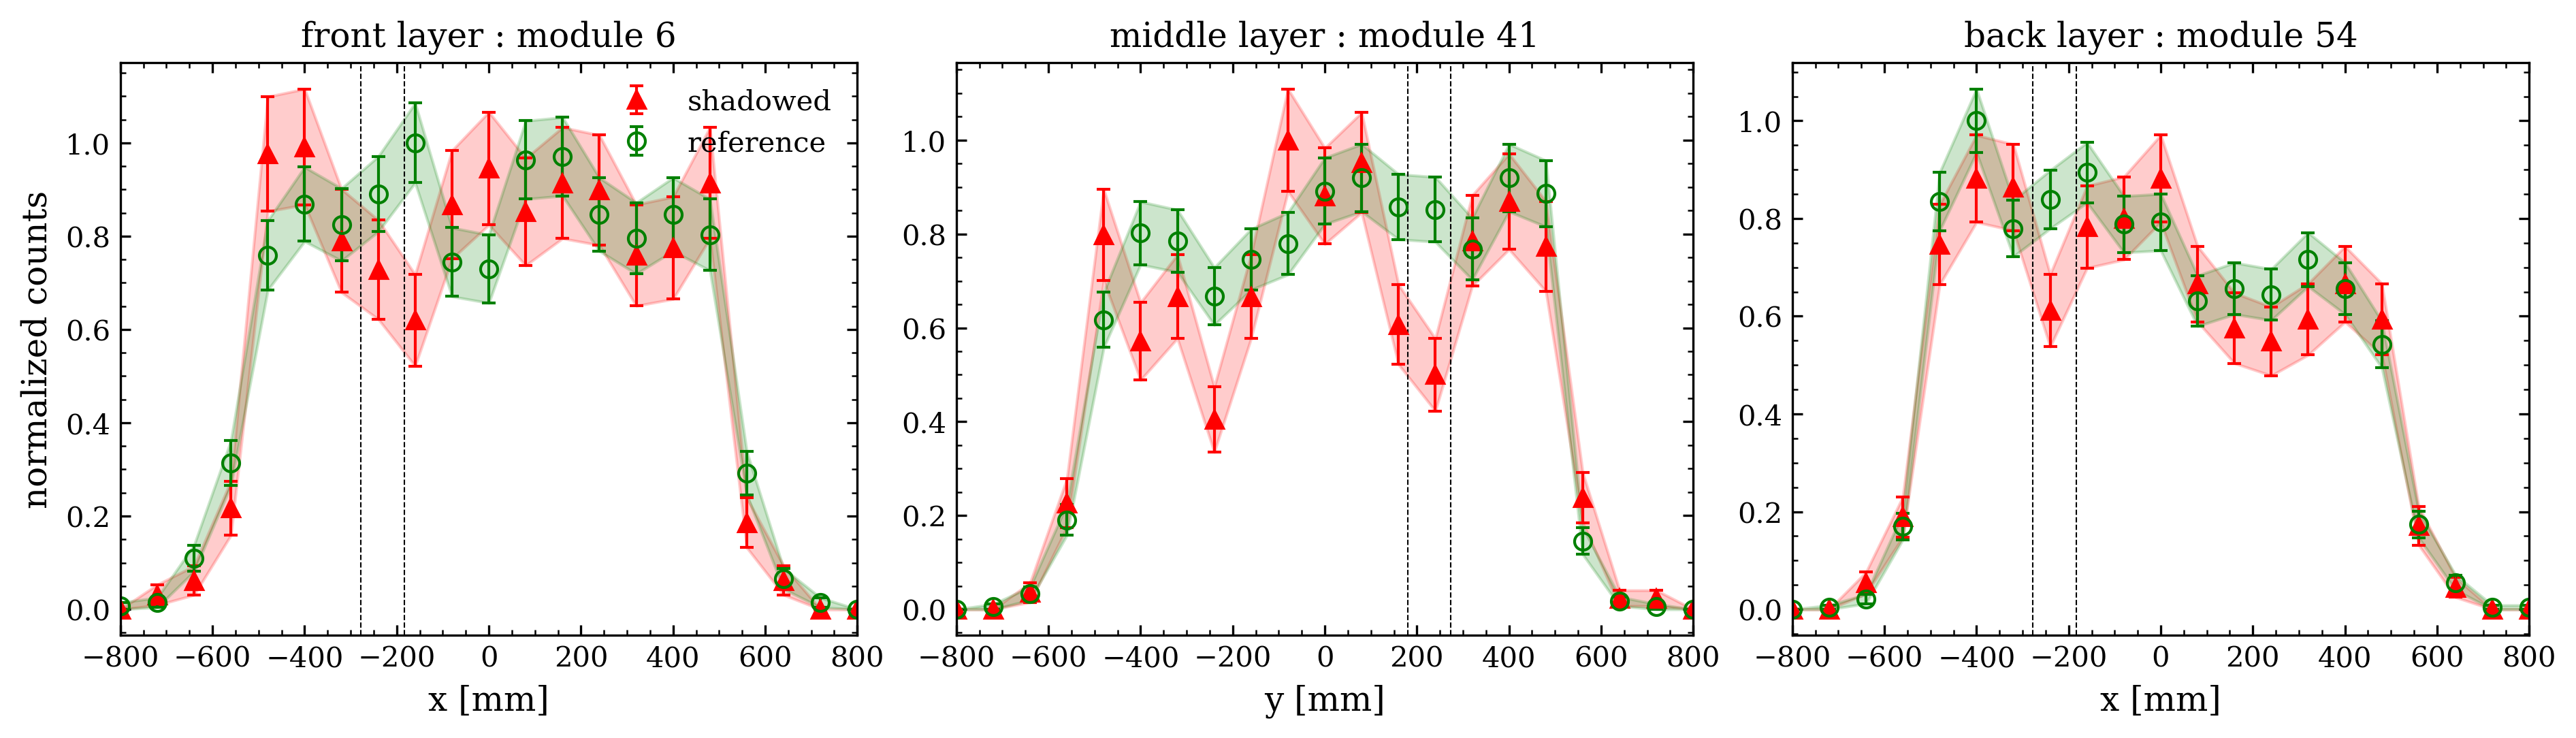

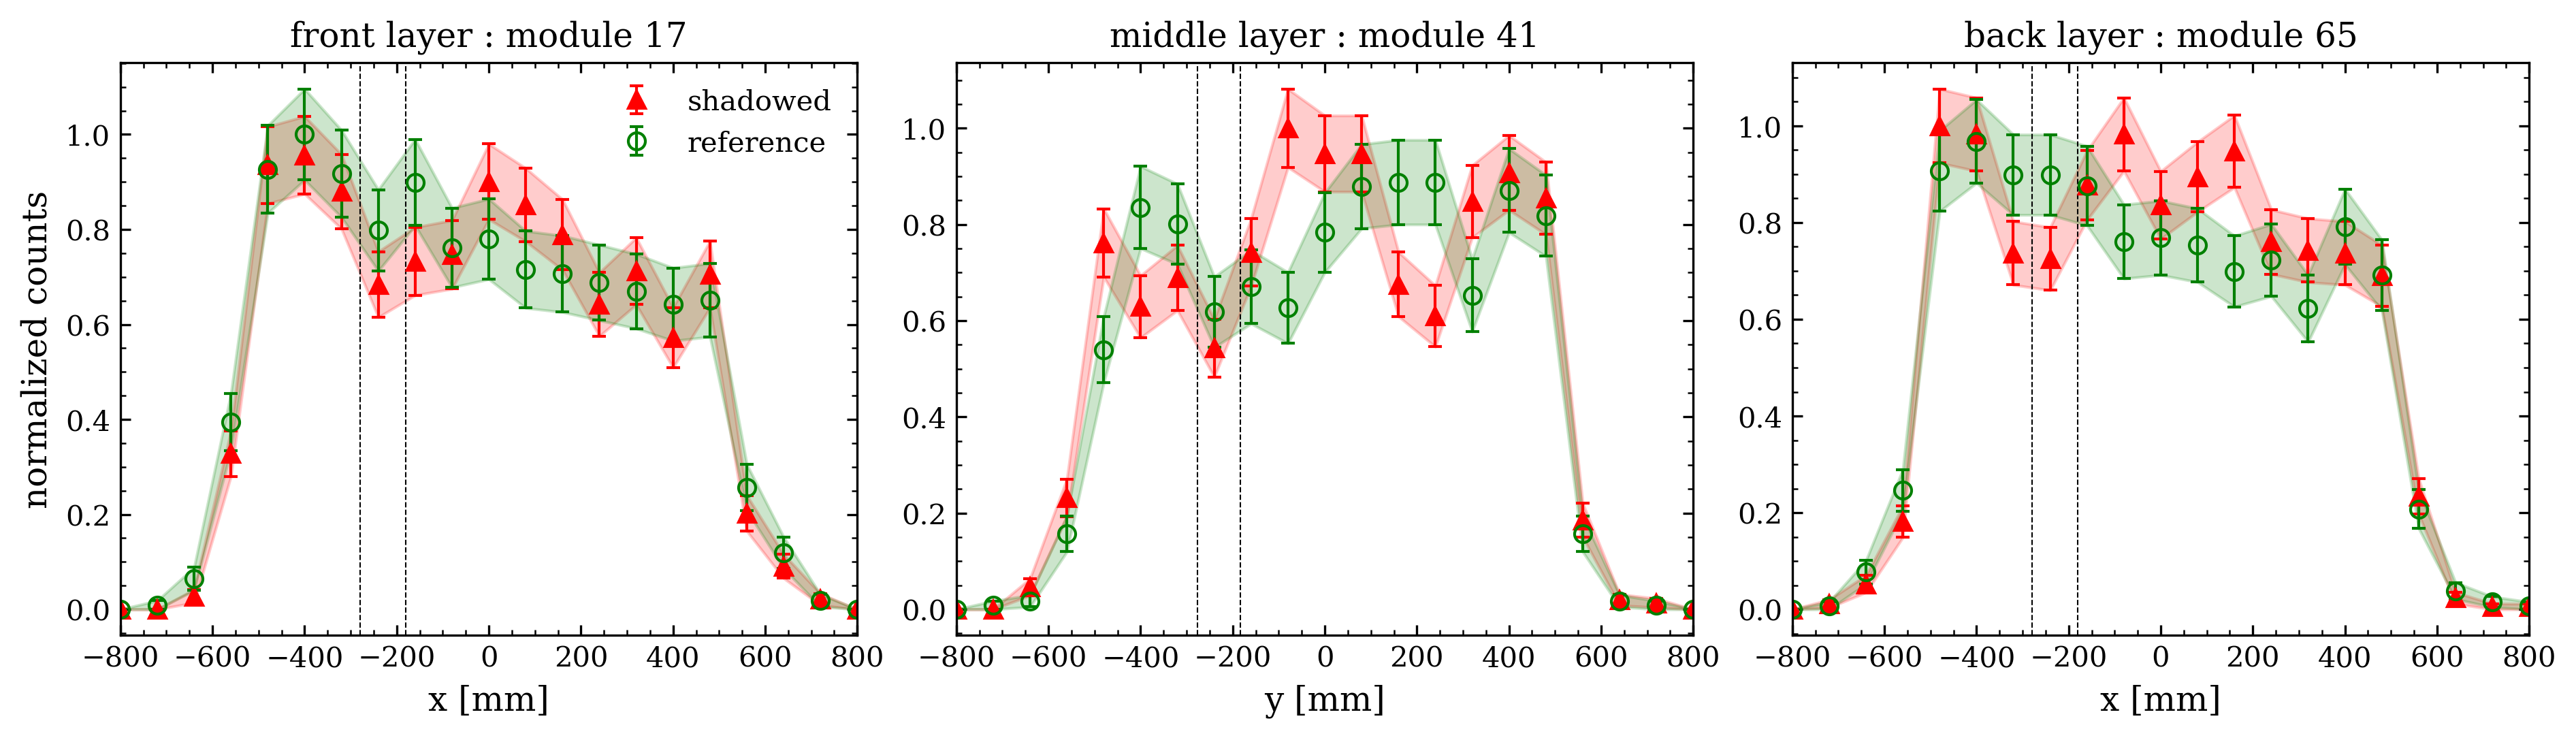

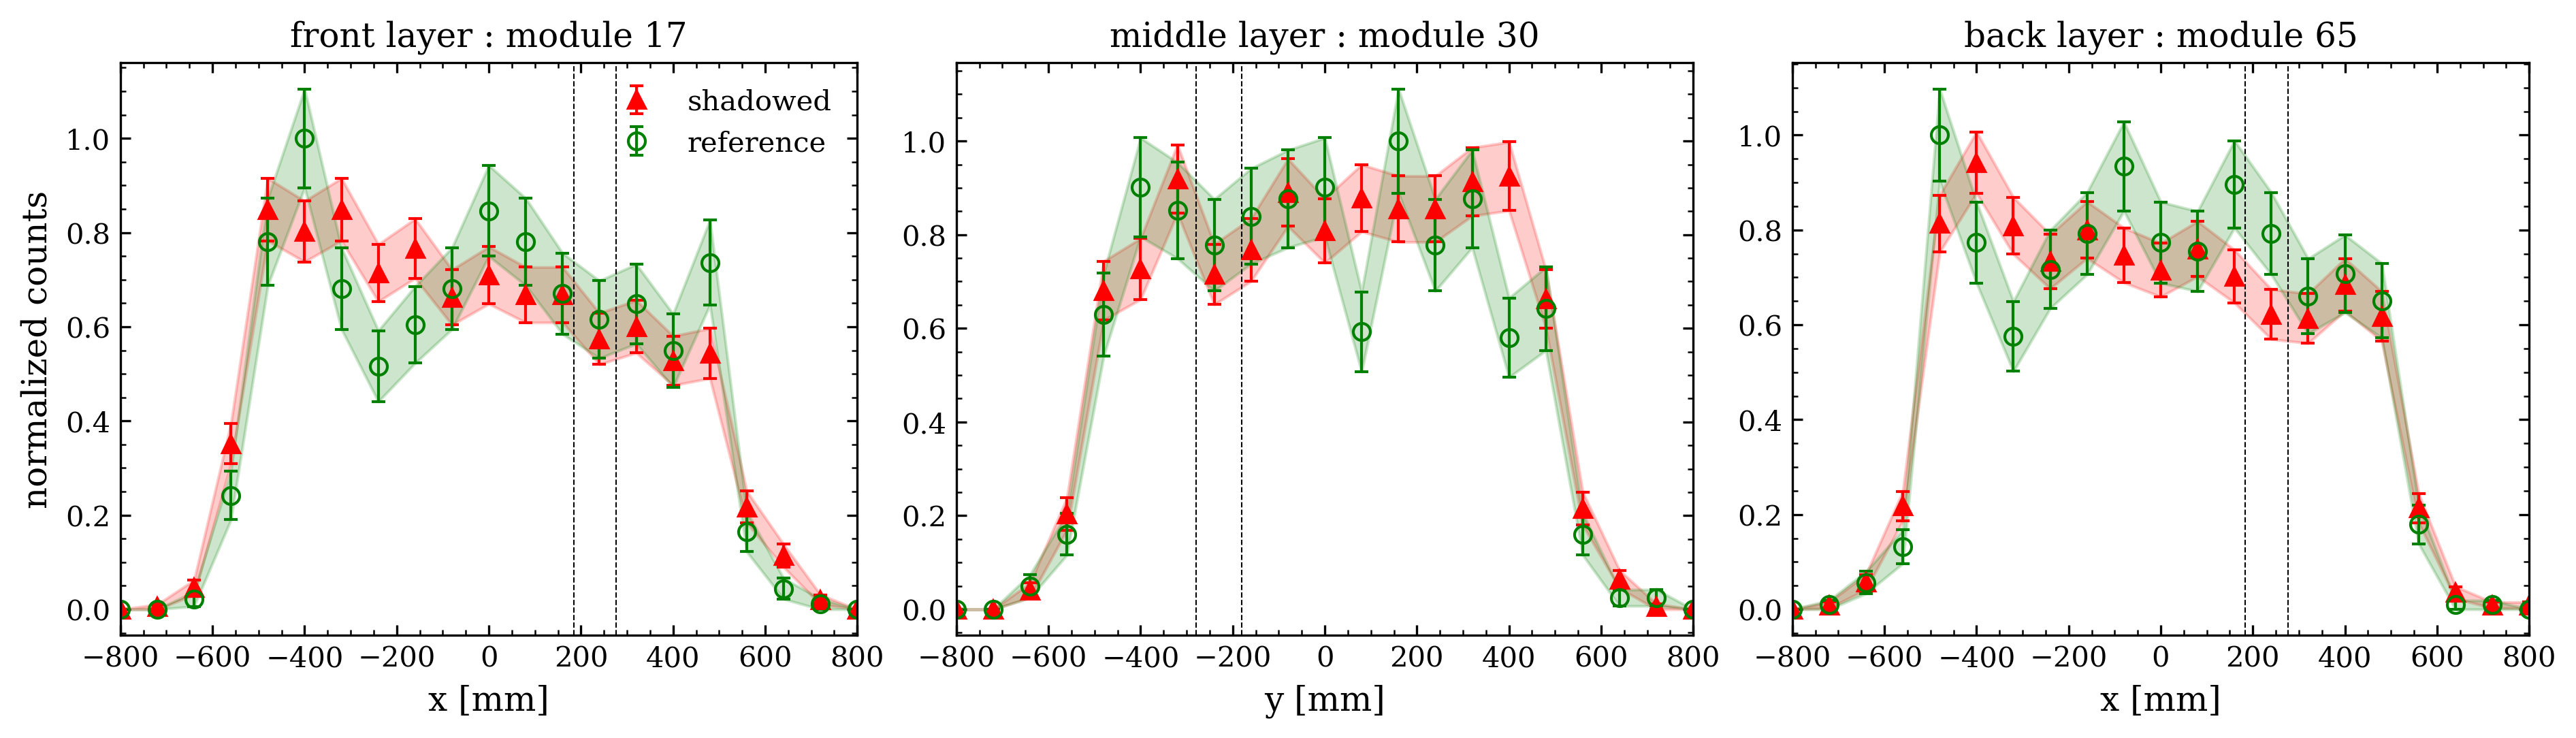

In [23]:
layer_label = {
    0 : 'front layer',
    1 : 'middle layer',
    2 : 'back layer',
}


for run, ref in shadow_ref.items():
    target_shadow = interested_bar[run]
    shadow_coor = shadow_bar_coordinates[target_shadow]
    
    fig, axes = plt.subplots(1,3, figsize=(12.5,3.5), constrained_layout=True, dpi=300)

    for i, mod in enumerate(covered_modules[target_shadow]):
        df_shadow = hist_shadow[run][mod].copy()
        df_ref = hist_shadow[ref][mod].copy()
        norm = df_shadow['y'].values.max()
        norm = max(norm, df_ref['y'].values.max())

        axes[i].errorbar(
            df_shadow['x'],
            df_shadow['y'] / norm,
            yerr=df_shadow['y_err'] / norm,
            elinewidth=1,
            capsize=2.5,
            marker='^',
            ls='none',
            color='r',
            label='shadowed'
        )

        axes[i].errorbar(
            df_ref['x'],
            df_ref['y'] / norm,
            yerr=df_ref['y_err'] / norm,
            elinewidth=1,
            capsize=2.5,
            marker='o',
            ls='none',
            color='g',
            markerfacecolor='none',
            label='reference'
        )

        axes[i].fill_between(
            df_shadow['x'],
            (df_shadow['y'] - df_shadow['y_err']) / norm, 
            (df_shadow['y'] + df_shadow['y_err']) / norm,
            color='r',
            alpha=0.2
        )

        axes[i].fill_between(
            df_ref['x'],
            (df_ref['y'] - df_ref['y_err']) / norm,
            (df_ref['y'] + df_ref['y_err']) / norm,
            color='g',
            alpha=0.2
        )

        if (i == 0 or i == 2):
            axes[i].axvline(shadow_coor[0][0], color='k', linestyle='--', linewidth=0.5)
            axes[i].axvline(shadow_coor[2][0], color='k', linestyle='--', linewidth=0.5)
            xrange = sorted([shadow_coor[0][0], shadow_coor[2][0]])
            axes[i].set_xlabel('x [mm]', fontsize=12)
        else:
            axes[i].axvline(shadow_coor[0][1], color='k', linestyle='--', linewidth=0.5)
            axes[i].axvline(shadow_coor[1][1], color='k', linestyle='--', linewidth=0.5)
            xrange = sorted([shadow_coor[0][1], shadow_coor[1][1]])
            axes[i].set_xlabel('y [mm]', fontsize=12)

        axes[i].set_title(f'{layer_label[i]} : module {mod}', fontsize=12)
        axes[i].set_xlim(-800,800)

        ref_counts = df_ref.query(f'x > {xrange[0]} and x < {xrange[1]}').y.sum()
        shadow_counts = df_shadow.query(f'x > {xrange[0]} and x < {xrange[1]}').y.sum()

        ratio=(ref_counts - shadow_counts) / ref_counts
        print(f'shadowbar {target_shadow} : module {mod} : {ratio}')



    axes[0].set_ylabel('normalized counts', fontsize=12)
    axes[0].legend(loc='upper right', fontsize=10, frameon=False)